Saved!


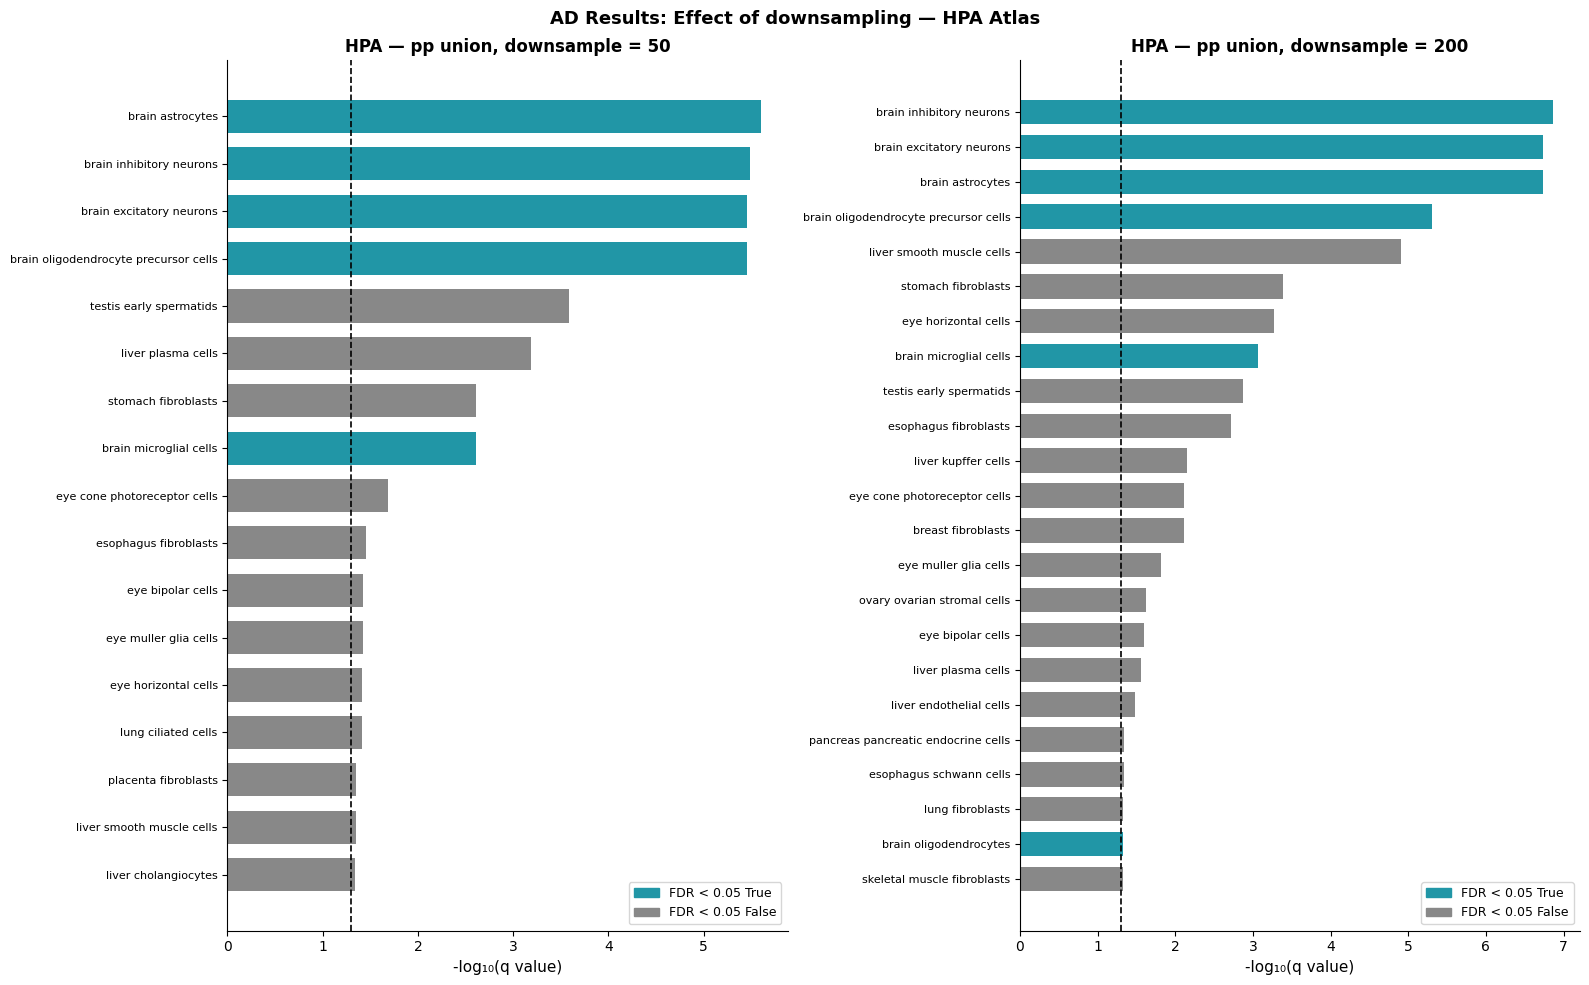

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load results
hpa_50 = pd.read_csv("/hpc/users/sucuy01/Yasemin_projects/gnpc_biomarker/updated_biomarker/biomarker-tracing/gnpc_run_results/pipeline_univar_multivar_hpa_pp_50/univar_association_testing/AD/univar_regression_results.tsv", sep="\t")

hpa_200 = pd.read_csv("/hpc/users/sucuy01/Yasemin_projects/gnpc_biomarker/updated_biomarker/biomarker-tracing/gnpc_run_results/results_discuss/pipeline_univar_multivar_pp_atlas/univar_association_testing/AD/univar_regression_results.tsv", sep="\t")

fdr_col = "fdr_one_side_predictor"

def prep(df, n=25):
    df = df[df[fdr_col] < 0.05].copy()
    df["log_fdr"] = -np.log10(df[fdr_col])
    df = df.sort_values("log_fdr", ascending=True).tail(n)
    return df

hpa_50_sig = prep(hpa_50)
hpa_200_sig = prep(hpa_200)

def is_brain(label):
    brain_terms = ["brain", "neuron", "astrocyte", "microglia", "oligodendro",
                   "gyrus", "prefrontal", "cortex", "cortical", "GABAergic", "glutamatergic"]
    return any(t.lower() in label.lower() for t in brain_terms)

hpa_50_sig["is_brain"] = hpa_50_sig["cell_tissue"].apply(is_brain)
hpa_200_sig["is_brain"] = hpa_200_sig["cell_tissue"].apply(is_brain)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor("white")

def plot_panel(ax, df, title):
    colors = ["#2196A6" if b else "#888888" for b in df["is_brain"]]
    ax.barh(range(len(df)), df["log_fdr"], color=colors, height=0.7)
    ax.axvline(x=-np.log10(0.05), color="black", linestyle="--", linewidth=1.2)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["cell_tissue"].str.replace("_", " ").str.replace(".", " "), fontsize=8)
    ax.set_xlabel("-log₁₀(q value)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    brain_patch = mpatches.Patch(color="#2196A6", label="FDR < 0.05 True")
    other_patch = mpatches.Patch(color="#888888", label="FDR < 0.05 False")
    ax.legend(handles=[brain_patch, other_patch], fontsize=9, loc="lower right")

plot_panel(axes[0], hpa_50_sig, "HPA — pp union, downsample = 50")
plot_panel(axes[1], hpa_200_sig, "HPA — pp union, downsample = 200")

plt.suptitle("AD Results: Effect of downsampling — HPA Atlas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/hpc/users/sucuy01/Yasemin_projects/gnpc_biomarker/updated_biomarker/biomarker-tracing/gnpc_run_results/hpa_50_vs_200_comparison.png", dpi=150, bbox_inches="tight")
print("Saved!")

Saved!


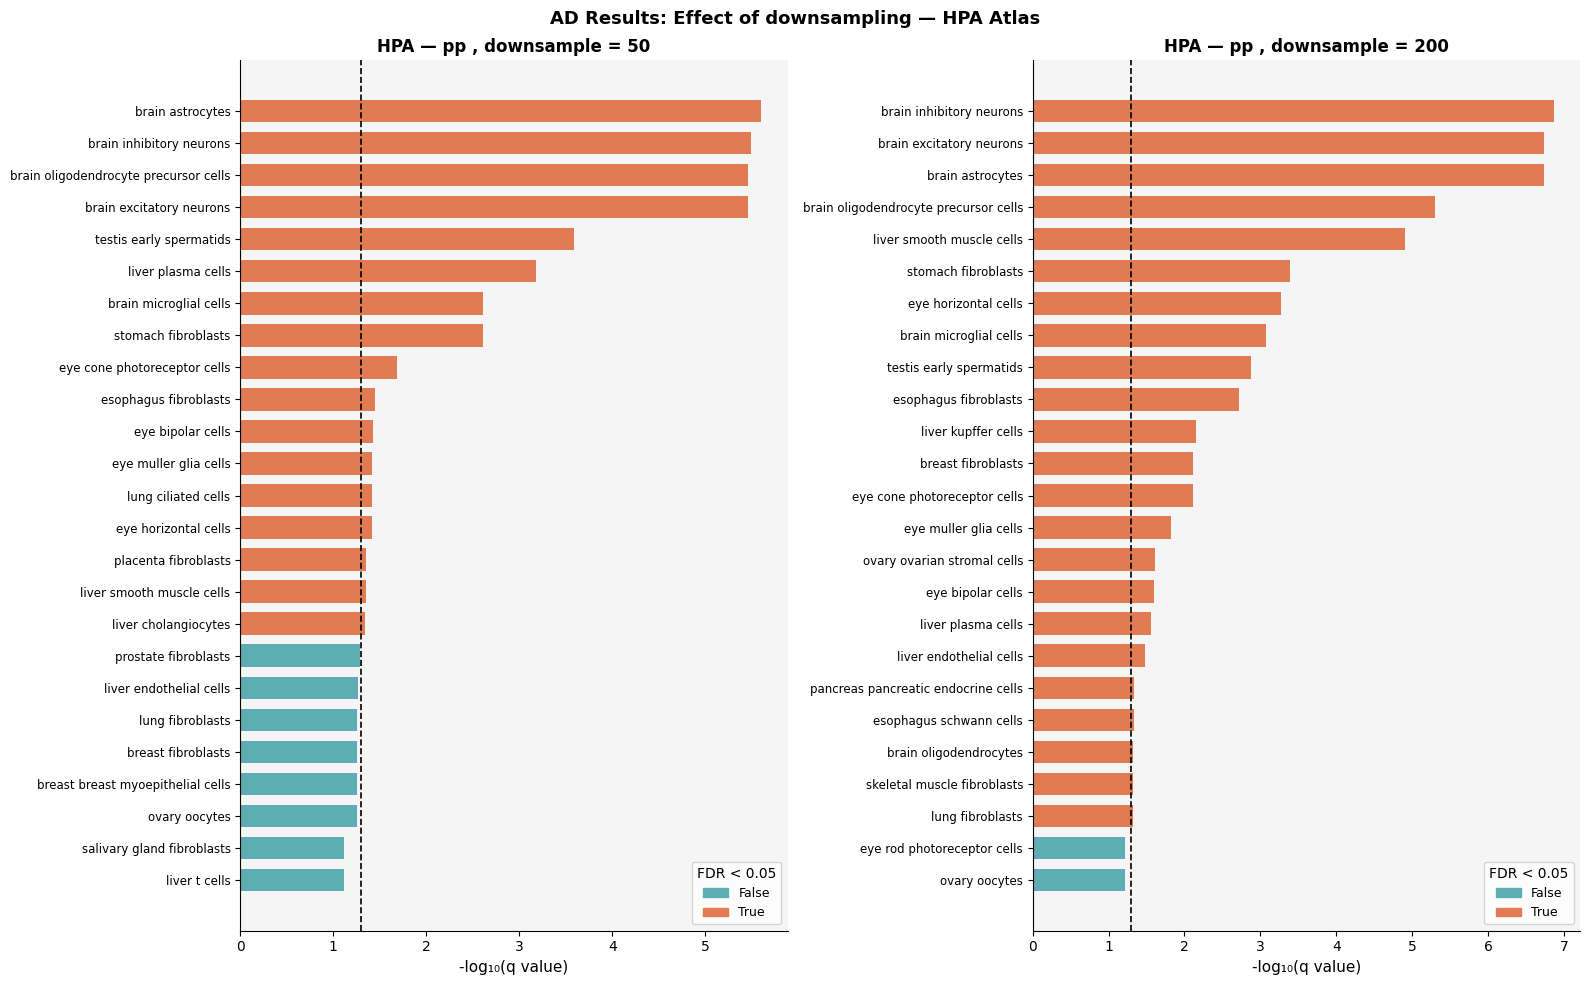

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

hpa_50 = pd.read_csv("/hpc/users/sucuy01/Yasemin_projects/gnpc_biomarker/updated_biomarker/biomarker-tracing/gnpc_run_results/pipeline_univar_multivar_hpa_pp_50/univar_association_testing/AD/univar_regression_results.tsv", sep="\t")

hpa_200 = pd.read_csv("/hpc/users/sucuy01/Yasemin_projects/gnpc_biomarker/updated_biomarker/biomarker-tracing/gnpc_run_results/results_discuss/pipeline_univar_multivar_pp_atlas/univar_association_testing/AD/univar_regression_results.tsv", sep="\t")

fdr_col = "fdr_one_side_predictor"

def prep(df, n=25):
    df = df.copy()
    df["log_fdr"] = -np.log10(df[fdr_col])
    df["sig"] = df[fdr_col] < 0.05
    df = df.sort_values("log_fdr", ascending=True).tail(n)
    return df

hpa_50_sig = prep(hpa_50)
hpa_200_sig = prep(hpa_200)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor("white")

def plot_panel(ax, df, title):
    colors = ["#E07B54" if s else "#5EADB5" for s in df["sig"]]
    ax.barh(range(len(df)), df["log_fdr"], color=colors, height=0.7)
    ax.axvline(x=-np.log10(0.05), color="black", linestyle="--", linewidth=1.2)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["cell_tissue"].str.replace("_", " ").str.replace(".", " "), fontsize=8.5)
    ax.set_xlabel("-log₁₀(q value)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("#F5F5F5")
    true_patch = mpatches.Patch(color="#E07B54", label="True")
    false_patch = mpatches.Patch(color="#5EADB5", label="False")
    ax.legend(handles=[false_patch, true_patch], title="FDR < 0.05", fontsize=9, loc="lower right")

plot_panel(axes[0], hpa_50_sig, "HPA — pp , downsample = 50")
plot_panel(axes[1], hpa_200_sig, "HPA — pp , downsample = 200")

plt.suptitle("AD Results: Effect of downsampling — HPA Atlas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/hpc/users/sucuy01/Yasemin_projects/gnpc_biomarker/updated_biomarker/biomarker-tracing/gnpc_run_results/hpa_50_vs_200_comparison.png", dpi=150, bbox_inches="tight")
print("Saved!")

Plot 1 saved!
Plot 2 saved!


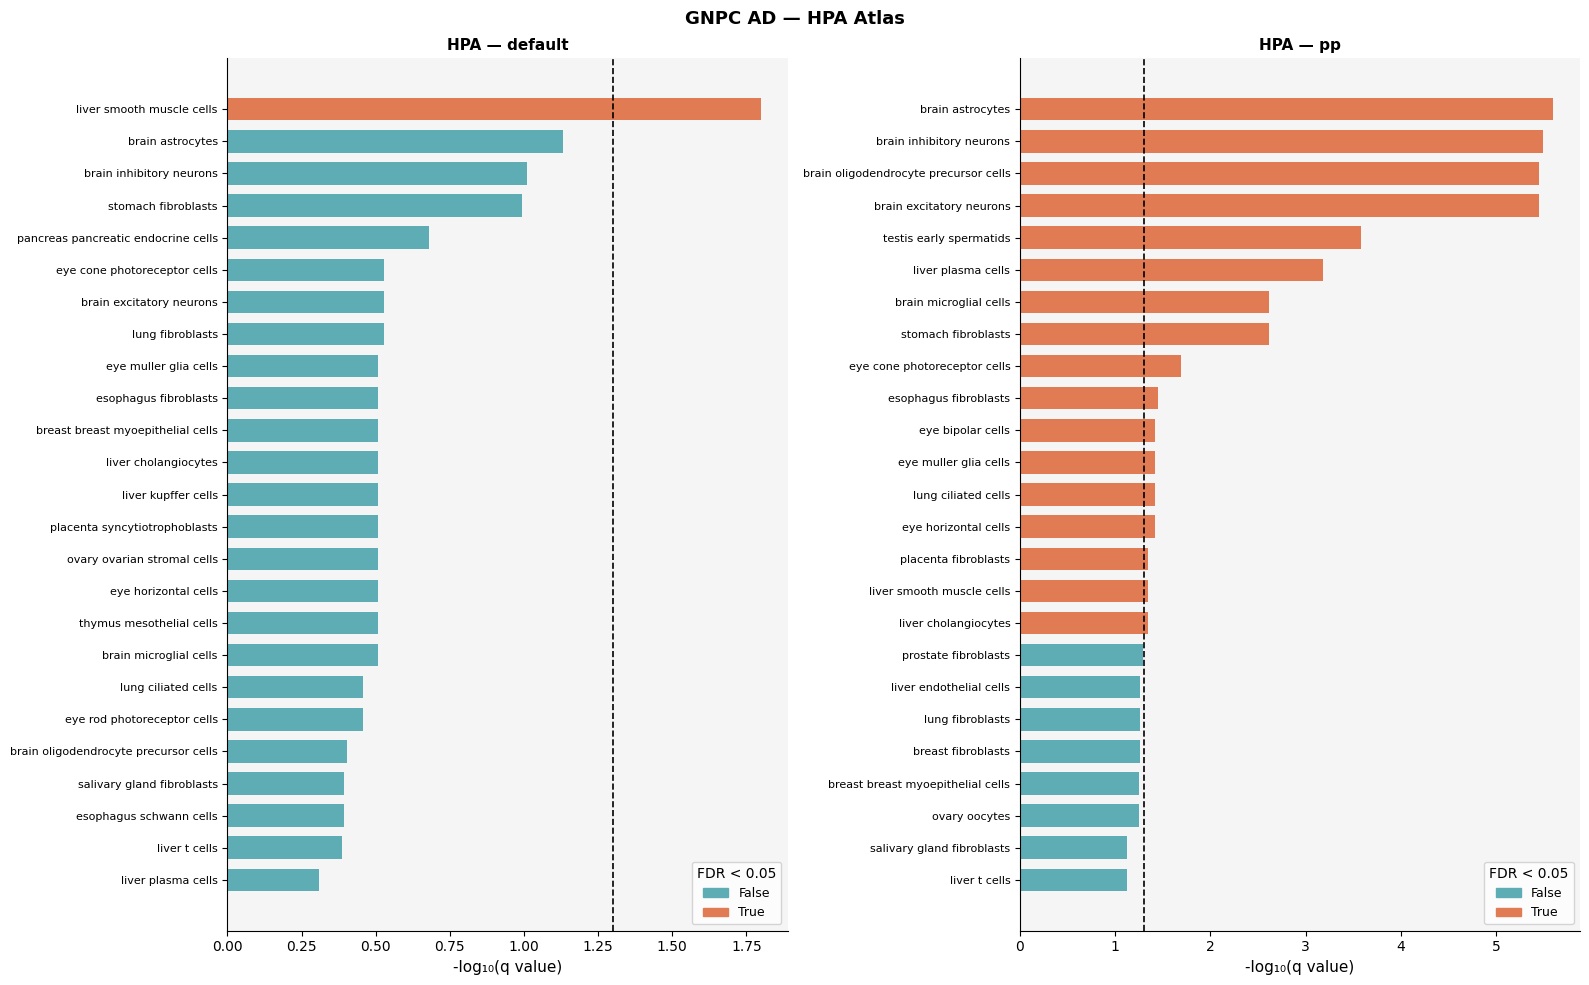

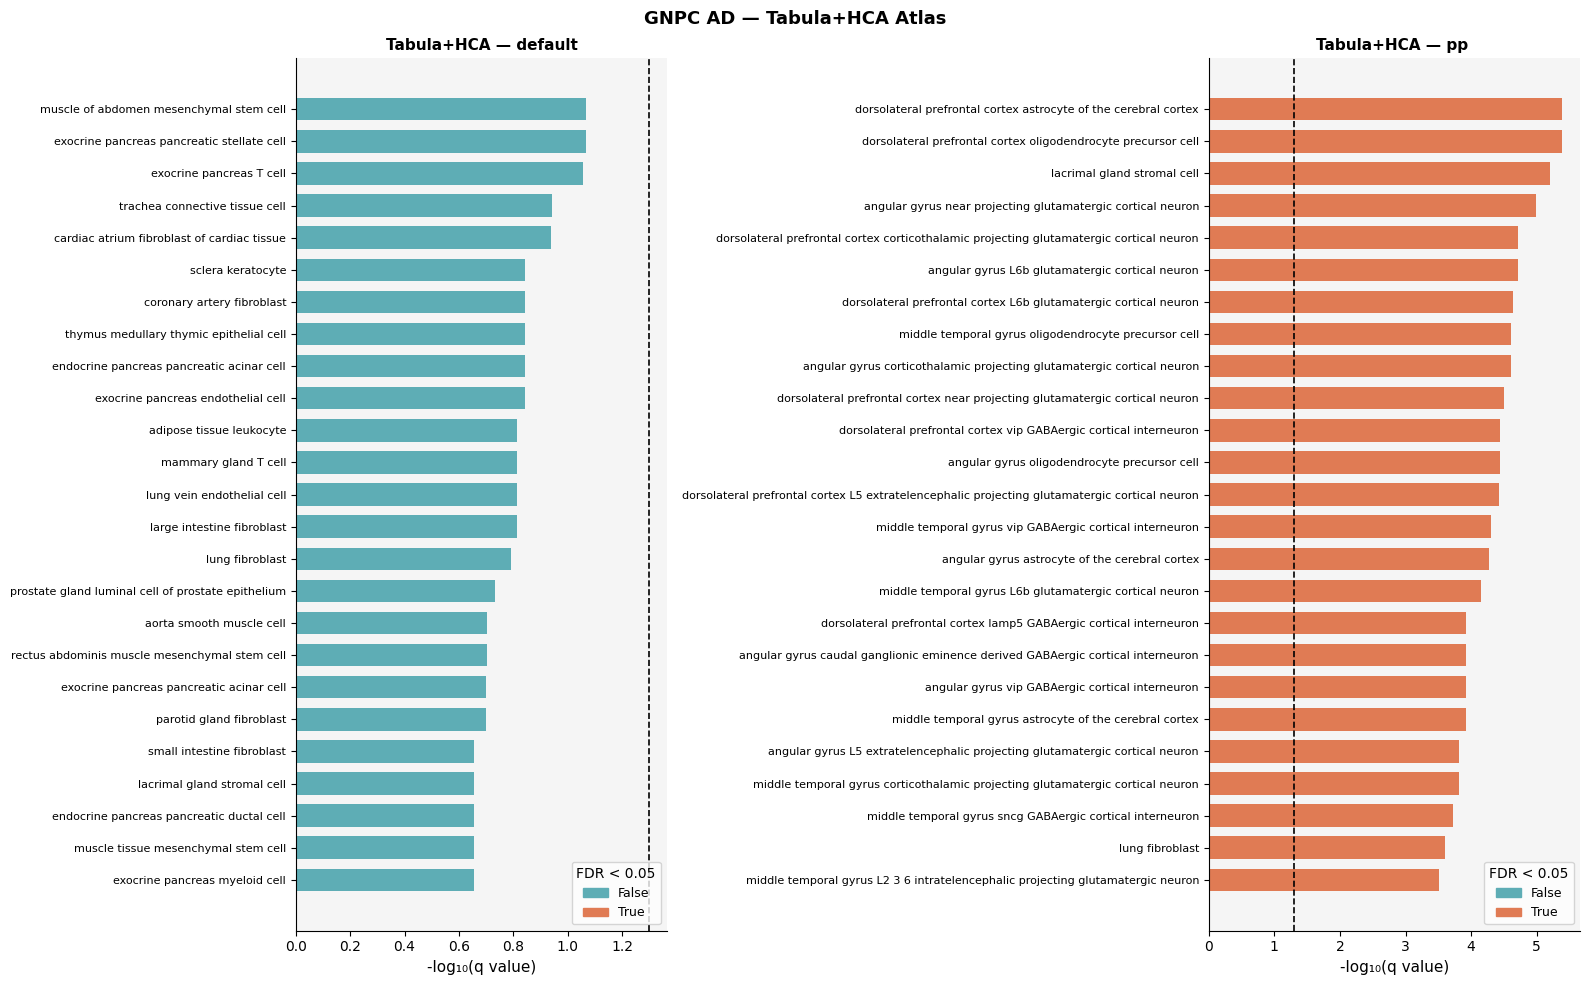

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

base = "/hpc/users/sucuy01/Yasemin_projects/gnpc_biomarker/updated_biomarker/biomarker-tracing/gnpc_run_results"

paths = {
    "hpa_default": f"{base}/results_discuss/pipeline_univar_multivar_default_atlas/univar_association_testing/AD/univar_regression_results.tsv",
    "hpa_pp_50": f"{base}/pipeline_univar_multivar_hpa_pp_50/univar_association_testing/AD/univar_regression_results.tsv",
    "ts_default_50": f"{base}/pipeline_univar_multivar_ts_hca_default_50/univar_association_testing/AD/univar_regression_results.tsv",
    "ts_pp_50": f"{base}/pipeline_univar_multivar_ts_hca_pp_50/univar_association_testing/AD/univar_regression_results.tsv",
}

fdr_col = "fdr_one_side_predictor"

def prep(df, n=25):
    df = df.copy()
    df["log_fdr"] = -np.log10(df[fdr_col])
    df["sig"] = df[fdr_col] < 0.05
    df = df.sort_values("log_fdr", ascending=True).tail(n)
    return df

def plot_panel(ax, df, title):
    colors = ["#E07B54" if s else "#5EADB5" for s in df["sig"]]
    ax.barh(range(len(df)), df["log_fdr"], color=colors, height=0.7)
    ax.axvline(x=-np.log10(0.05), color="black", linestyle="--", linewidth=1.2)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["cell_tissue"].str.replace("_", " ").str.replace(".", " "), fontsize=8)
    ax.set_xlabel("-log₁₀(q value)", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("#F5F5F5")
    true_patch = mpatches.Patch(color="#E07B54", label="True")
    false_patch = mpatches.Patch(color="#5EADB5", label="False")
    ax.legend(handles=[false_patch, true_patch], title="FDR < 0.05", fontsize=9, loc="lower right")

dfs = {k: prep(pd.read_csv(v, sep="\t")) for k, v in paths.items()}

# Plot 1 — HPA: default vs pp-50
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor("white")
plot_panel(axes[0], dfs["hpa_default"], "HPA — default")
plot_panel(axes[1], dfs["hpa_pp_50"], "HPA — pp")
plt.suptitle("GNPC AD — HPA Atlas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{base}/hpa_default_vs_pp_comparison.png", dpi=150, bbox_inches="tight")
print("Plot 1 saved!")

# Plot 2 — Tabula+HCA: default vs pp-50
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.patch.set_facecolor("white")
plot_panel(axes[0], dfs["ts_default_50"], "Tabula+HCA — default")
plot_panel(axes[1], dfs["ts_pp_50"], "Tabula+HCA — pp ")
plt.suptitle("GNPC AD — Tabula+HCA Atlas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{base}/ts_hca_default_vs_pp_comparison.png", dpi=150, bbox_inches="tight")
print("Plot 2 saved!")